<a href="https://colab.research.google.com/github/tixomirof/mo2_team_colabs/blob/main/%D0%9C%D0%9E2_%D0%9A%D0%BE%D0%BC%D0%B0%D0%BD%D0%B4%D0%B02_%D0%9B%D0%B0%D0%B107_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Шапка

Проектная работа. Группа №2. Обучение с учителем: градиентный спуск и AdaBoost.

Участники команды:

* Ибраева Асем Балташевна
* Киреева Анастасия Игоревна
* Рудин Валентин Константинович
* Тихомиров Алексей Константинович


# Методы на основе деревьев

## Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Загрузка данных

In [4]:
df = pd.read_csv('Engineered_Data.csv')
df.head()

,Employment,YearsCode,YearsCodePro,PreviousSalary,ComputerSkills,Employed,APL,ASP.NET,ASP.NET Core,AWS,...,Age_>35,Accessibility_Yes,EdLevel_NoHigherEd,EdLevel_Other,EdLevel_PhD,EdLevel_Undergraduate,Gender_NonBinary,Gender_Woman,MentalHealth_Yes,MainBranch_NotDev
0,1,7.0,4,51552.0,4,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,1,12.0,5,46482.0,12,1,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False
2,1,15.0,6,77290.0,7,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,1,9.0,6,46135.0,13,0,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False
4,0,40.0,30,160932.0,2,0,0,0,0,0,...,True,False,False,False,True,False,False,False,False,True


Как и раньше, будем использовать уже подготовленный датасет `Engineered_Data.csv`. Анализ данных был проведен ранее.


## Подготовка данных

In [6]:
X = df.drop('Employed', axis=1)
y = df['Employed']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=101
)

X_train.shape, X_test.shape

((48780, 132), (20906, 132))

# Расширяемые деревья (Boosted Trees)

Мы уже посмотрелы деревья решений и случайные леса в предыдущей лабораторной работе.

Напоминание:
*   Дерево решений дало 99.82% верных результатов на тестовой выборке.
*   Случайный лес дал 96.28% верных результатов на тестовой выборке.



### Gradient Boosting

In [7]:
gb_param_grid = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'subsample': [1.0, 0.8],
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=101),
    gb_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
)
gb_grid.fit(X_train, y_train)
gb_grid.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150, 'subsample': 0.8}

In [8]:
gb_grid.best_score_

np.float64(0.9989134891348913)

In [9]:
best_gb = gb_grid.best_estimator_
gb_preds = best_gb.predict(X_test)
accuracy_score(y_test, gb_preds)

0.9989955036831532

In [10]:
print(classification_report(y_test, gb_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9989    0.9990    0.9989      9690
           1     0.9991    0.9990    0.9991     11216

    accuracy                         0.9990     20906
   macro avg     0.9990    0.9990    0.9990     20906
weighted avg     0.9990    0.9990    0.9990     20906



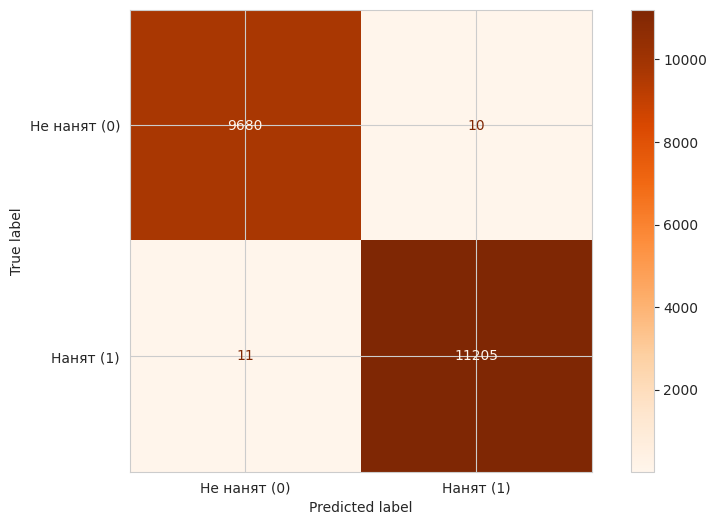

In [11]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    gb_preds,
    display_labels=['Не нанят (0)', 'Нанят (1)'],
    cmap='Oranges'
)
plt.show()

In [12]:
gb_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_gb.feature_importances_
}).sort_values('importance', ascending=False)

gb_feature_importance.head(10)

,feature,importance
4,ComputerSkills,0.387700
73,Microsoft SQL Server,0.093209
78,Node.js,0.091484
111,TypeScript,0.088580
16,C#,0.076353
119,jQuery,0.051277
120,npm,0.050139
74,MongoDB,0.043886
59,Java,0.042830
103,SQLite,0.039514


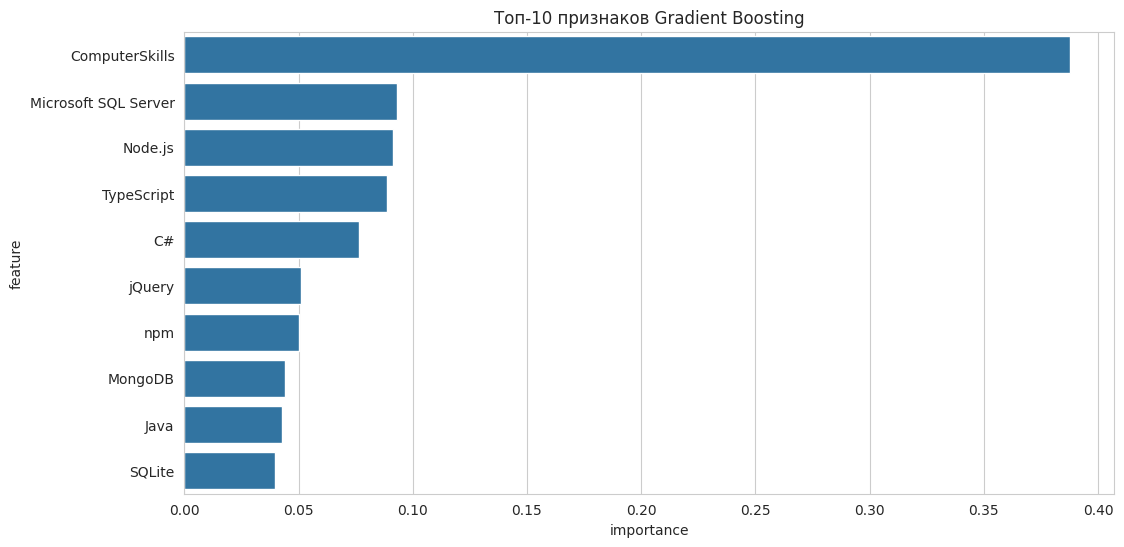

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(data=gb_feature_importance.head(10), x='importance', y='feature')
plt.title('Топ-10 признаков Gradient Boosting')
plt.show()

Gradient Boosting показал точность 99.9% на тестовой выборке. Хороший результат.

Больше всего Gradient Boosting ценит признак `ComputerSkills`.


### AdaBoost

In [14]:
ab_param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.5, 1.0],
}

ab_grid = GridSearchCV(
    AdaBoostClassifier(random_state=101),
    ab_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
)
ab_grid.fit(X_train, y_train)
ab_grid.best_params_

{'learning_rate': 1.0, 'n_estimators': 100}

In [15]:
ab_grid.best_score_

np.float64(1.0)

In [16]:
best_ab = ab_grid.best_estimator_
ab_preds = best_ab.predict(X_test)
accuracy_score(y_test, ab_preds)

1.0

In [17]:
print(classification_report(y_test, ab_preds, digits=4))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      9690
           1     1.0000    1.0000    1.0000     11216

    accuracy                         1.0000     20906
   macro avg     1.0000    1.0000    1.0000     20906
weighted avg     1.0000    1.0000    1.0000     20906



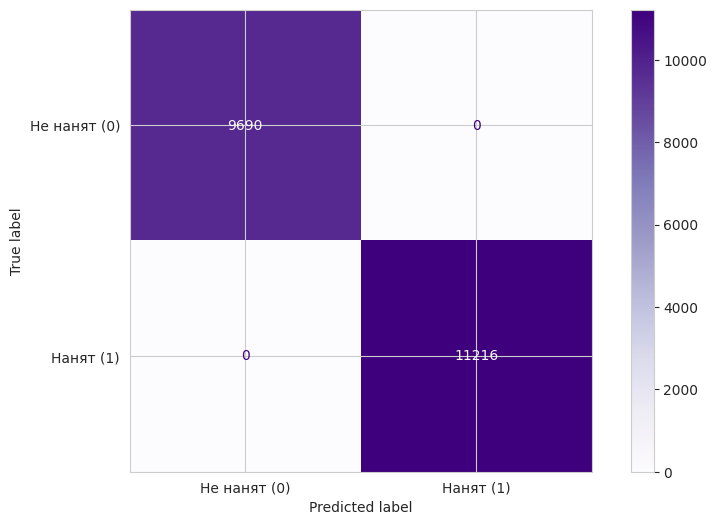

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    ab_preds,
    display_labels=['Не нанят (0)', 'Нанят (1)'],
    cmap='Purples'
)
plt.show()

In [19]:
ab_feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_ab.feature_importances_
}).sort_values('importance', ascending=False)

ab_feature_importance.head(10)

,feature,importance
59,Java,0.120635
73,Microsoft SQL Server,0.103113
120,npm,0.102171
119,jQuery,0.099040
103,SQLite,0.098106
13,Bash/Shell,0.097317
74,MongoDB,0.090000
16,C#,0.089385
78,Node.js,0.088330
111,TypeScript,0.066970


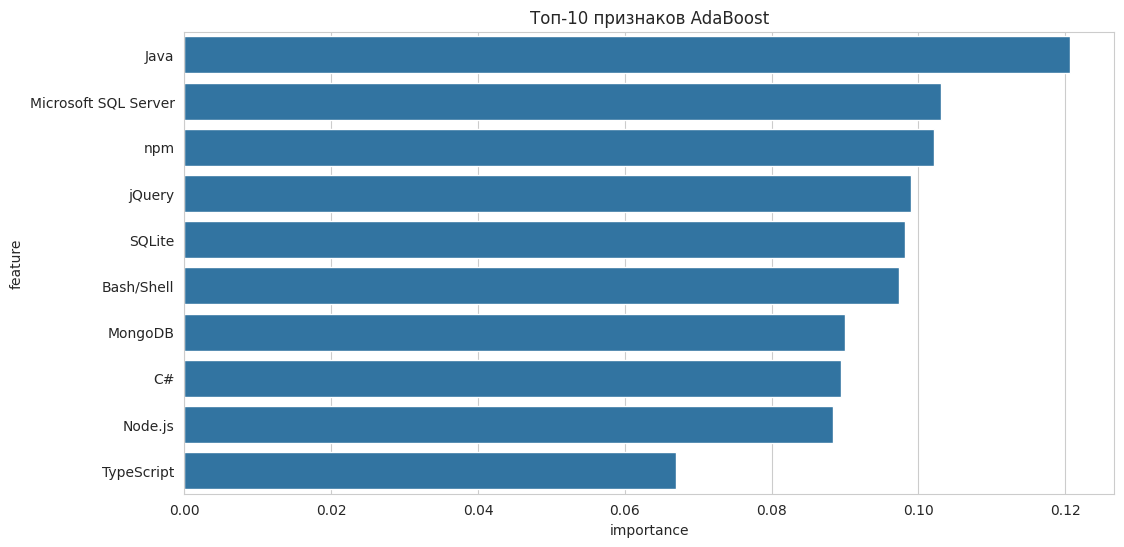

In [20]:
plt.figure(figsize=(12, 6))
sns.barplot(data=ab_feature_importance.head(10), x='importance', y='feature')
plt.title('Топ-10 признаков AdaBoost')
plt.show()

AdaBoost дал 100%-ую точность на тестовой выборке.

В отличие от Gradient Boosting, `ComputerSkills` не вошел даже в топ-10. Однако все топ-10 признаков исходят из `ComputerSkills`.


# Итоговое сравнение моделей "Обучение с учителем"

Модуль "обучение с учителем" подходит к концу. А это значит, что можно подвести итоги. Сравним каждую модель.

In [29]:
comparison_df = pd.DataFrame([
    {
        'model': 'Логистическая регрессия',
        'test_accuracy': 1.0
    },
    {
        'model': 'KNN',
        'test_accuracy': 0.83
    },
    {
        'model': 'SVM',
        'test_accuracy': 1.0
    },
    {
        'model': 'Дерево решений',
        'test_accuracy': 0.997
    },
    {
        'model': 'Случайный лес',
        'test_accuracy': 0.9628
    },
    {
        'model': 'Gradient Boosting',
        'test_accuracy': accuracy_score(y_test, gb_preds),
    },
    {
        'model': 'AdaBoost',
        'test_accuracy': accuracy_score(y_test, ab_preds),
    },
]).sort_values('test_accuracy', ascending=False)

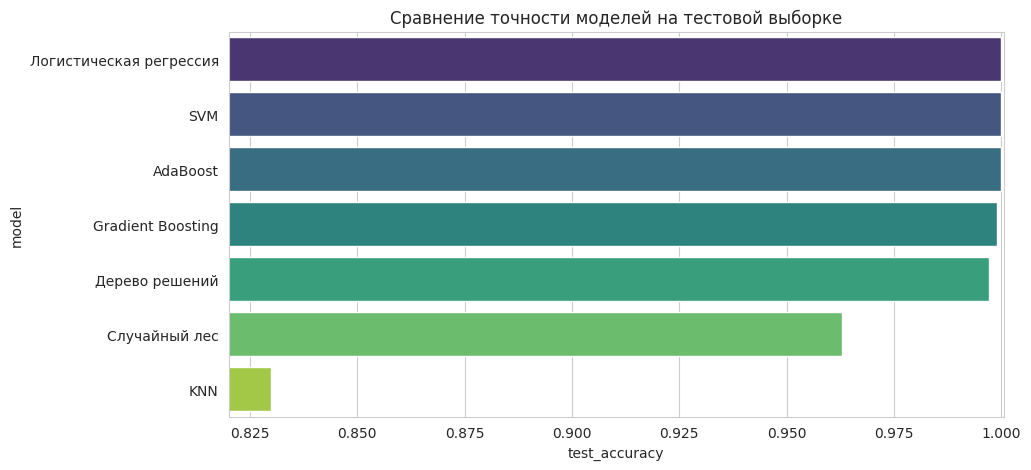

In [30]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='test_accuracy', y='model', palette='viridis')
plt.xlim(0.82, 1.0005)
plt.title('Сравнение точности моделей на тестовой выборке')
plt.show()

Посмотрим поближе, отбросив KNN и Random Forest.

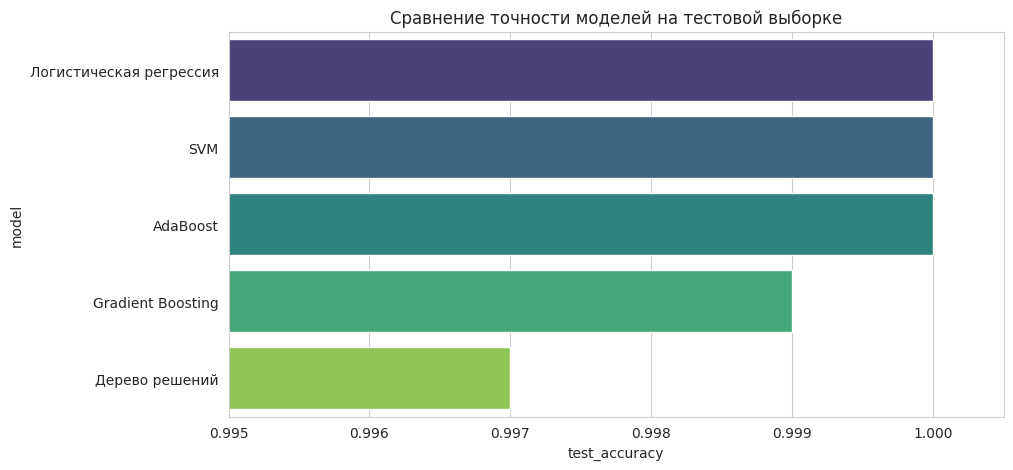

In [34]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df[~comparison_df['model'].isin(['Случайный лес', 'KNN'])],
            x='test_accuracy', y='model', palette='viridis')
plt.xlim(0.995, 1.0005)
plt.title('Сравнение точности моделей на тестовой выборке')
plt.show()

Самыми лучшими моделями оказались:
*   Логистическая регрессия
*   SVM
*   AdaBoost

Каждая из них дала 100%-ую точность на тестовой выборке. Далее планируется провести более точную проверку и выявить причину аномалии 100%-ой точности.
